# Do the two PD subtypes differ?

The within-subtype fits estimate the colour x medication interaction separately in TD-PD and BD-PD.
Finding that one interval excludes zero and the other does not is not a test of whether the
subtypes differ. This notebook tests that directly.

### Joint model

The within-subtype equation with subtype added and every two- and three-way interaction with it:

```
choice ~ subtype * (signed coherence + color * medication + previous rewarded choice * medication)
```

- Subtype is effect-coded, BD-PD = -0.5 and TD-PD = +0.5, so `sub:col:med` is TD-PD minus BD-PD.
- Priors and sampler settings are those of the reported within-subtype fits (`FIT_SETTINGS`).
- Random intercept and random slopes by participant on the seven within-participant terms, with
  standard deviations shared across subtypes. Subtype is between-participant, so it and its
  interactions get no random slope.

### Comparisons reported

| Estimate | What it assumes |
|---|---|
| 1. Three-way coefficient `sub:col:med` | Joint model; the primary test |
| 2. Difference in mean participant-level effect, draw by draw from the joint posterior | Same model as 1; differs only by the groups' average random slopes |
| 3. Difference of the two separately fitted `col:med` posteriors | Separate between-participant variances per subtype |
| 4. Bootstrap over participants of the per-participant posterior means from 2.26 | Treats each posterior mean as a data point; ignores their uncertainty |

Estimate 2 is close to estimate 1 almost by construction, so it is a consistency check, not
independent evidence. Estimate 3 is the one that relaxes an assumption. Estimate 4 is included for
comparison only.

Writes only to the gitignored `outputs/` directory.


In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2
from imports import *


In [2]:
import pymc as pm

from config import dir_config
from src.utils import classification_utils
from src.utils.mcmc_cache import CACHE_DIR, FIT_SETTINGS, TERMS, ess_bulk, prepare_trials, rhat

processed_dir = Path(dir_config.data.processed)
filtered_data = pd.read_csv(Path(processed_dir, "processed_all_data_accu_60_filtered.csv"), index_col=None)
processed_metadata = pd.read_csv(Path(processed_dir, "processed_metadata_all_data_accu_60.csv"), index_col=None)
subjects_map, _ = classification_utils.get_subject_classification_ids(processed_metadata)

OUTPUT_DIR = (Path.cwd().parent / "outputs").resolve()
assert not str(OUTPUT_DIR).startswith(str(processed_dir.parents[0])), "never write to the data dir"
OUTPUT_DIR.mkdir(exist_ok=True)

SUBTYPE_CODE = {"tremor": 0.5, "bradykinetic": -0.5}
SUBTYPE_KEYS = {"tremor": "tremor_dominant", "bradykinetic": "bradykinesia_dominant"}
WITHIN = TERMS                                             # the seven within-participant terms
JOINT_TERMS = WITHIN + [f"sub:{t}" if t != "intercept" else "sub" for t in WITHIN]
print(JOINT_TERMS)


PD subjects with ON+OFF sessions: 41
PD subjects with UPDRS subtype: 22
All PD subjects:           41
  Tremor dominant:         11 	 ['P3' 'P6' 'P7' 'P11' 'P12' 'P17' 'P18' 'P19' 'P29' 'P31' 'P32']
  Brady dominant:          10 	 ['P1' 'P4' 'P9' 'P13' 'P20' 'P22' 'P23' 'P28' 'P33' 'P34']
  Intermediate:            1 	 ['P24']
HC subjects:               18 	 ['HC1' 'HC3' 'HC6' 'HC7' 'HC8' 'HC9' 'HC12' 'HC13' 'AV' 'BC' 'BF' 'EM'
 'ES' 'GF' 'GP' 'JA' 'MRM' 'SY']
['intercept', 'coh', 'col', 'med', 'col:med', 'prev_rc', 'prev_rc:med', 'sub', 'sub:coh', 'sub:col', 'sub:med', 'sub:col:med', 'sub:prev_rc', 'sub:prev_rc:med']


## Data


In [3]:
frames = []
for subtype, key in SUBTYPE_KEYS.items():
    frames.append(prepare_trials(filtered_data, subjects_map[key]).assign(subtype=subtype, sub=SUBTYPE_CODE[subtype]))
joint = pd.concat(frames, ignore_index=True)

participants = joint["subject_id"].unique()
participant_index = joint["subject_id"].map({s: i for i, s in enumerate(participants)}).to_numpy()
participant_sub = joint.groupby("subject_id", sort=False)["sub"].first().reindex(participants).to_numpy()

within = np.column_stack([np.ones(len(joint)), joint["coh"], joint["col"], joint["med"],
                          joint["col"] * joint["med"], joint["prev_rc"], joint["prev_rc"] * joint["med"]])
design = np.column_stack([within, within * joint["sub"].to_numpy()[:, None]]).astype("float64")
outcomes = joint["choice"].to_numpy().astype("int8")

print(f"{len(participants)} participants ({(participant_sub > 0).sum()} TD-PD, {(participant_sub < 0).sum()} BD-PD), "
      f"{len(joint):,} trials, {design.shape[1]} population-level effects")
assert design.shape[1] == len(JOINT_TERMS)


21 participants (11 TD-PD, 10 BD-PD), 26,047 trials, 14 population-level effects


## Fit

Same priors and settings as the reported within-subtype fits. Random effects apply to the seven
within-participant columns only. Expect a few minutes.


In [4]:
n_within = len(WITHIN)
with pm.Model():
    population = pm.Normal("beta", 0, 2.5, shape=design.shape[1])
    subject_sd = pm.HalfNormal("sd_u", 1.0, shape=n_within)
    subject_z = pm.Normal("z_u", 0, 1, shape=(len(participants), n_within))
    # element-wise sums rather than pm.math.dot: a multithreaded dot product can change summation
    # order between runs, and the sampler amplifies those rounding differences
    eta = pm.math.sum(design * population, axis=1) + pm.math.sum(
        design[:, :n_within] * (subject_z * subject_sd)[participant_index], axis=1)
    pm.Bernoulli("obs", logit_p=eta, observed=outcomes)
    idata = pm.sample(FIT_SETTINGS["draws"], tune=FIT_SETTINGS["tune"], chains=FIT_SETTINGS["chains"],
                      cores=FIT_SETTINGS["chains"], target_accept=FIT_SETTINGS["target_accept"],
                      random_seed=FIT_SETTINGS["seed"], progressbar=False)

beta = idata.posterior["beta"].values          # (chain, draw, term)
sd_u = idata.posterior["sd_u"].values
z_u = idata.posterior["z_u"].values


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 193 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


## Diagnostics


In [5]:
diag = pd.DataFrame({
    "r_hat": [rhat(beta[..., k]) for k in range(beta.shape[-1])] + [rhat(sd_u[..., k]) for k in range(n_within)],
    "ess_bulk": [ess_bulk(beta[..., k]) for k in range(beta.shape[-1])] + [ess_bulk(sd_u[..., k]) for k in range(n_within)],
}, index=JOINT_TERMS + [f"sd_u[{t}]" for t in WITHIN])
print(f"divergences: {int(idata.sample_stats['diverging'].values.sum())}   "
      f"max r_hat: {diag['r_hat'].max():.4f}   min ESS: {diag['ess_bulk'].min():.0f}")
diag.round(4)


divergences: 0   max r_hat: 1.0073   min ESS: 479


,r_hat,ess_bulk
intercept,1.0024,896.5123
coh,1.0073,525.8892
col,1.0052,855.5733
med,1.0017,844.1349
col:med,1.0029,920.6373
prev_rc,1.0021,888.1897
prev_rc:med,1.0023,1328.8397
sub,1.0025,765.1420
sub:coh,1.0067,478.7498
sub:col,1.0021,868.4660


## Population-level posterior


In [6]:
pooled = beta.reshape(-1, beta.shape[-1])


def describe(draws):
    low, high = np.percentile(draws, [2.5, 97.5])
    return {"mean": draws.mean(), "SD": draws.std(), "2.5%": low, "97.5%": high, "P(> 0)": (draws > 0).mean()}


pd.DataFrame({t: describe(pooled[:, k]) for k, t in enumerate(JOINT_TERMS)}).T.round(4)


,mean,SD,2.5%,97.5%,P(> 0)
intercept,0.0326,0.0600,-0.0852,0.1532,0.7173
coh,3.3258,0.3510,2.5877,3.9870,1.0000
col,0.2814,0.0887,0.1054,0.4552,0.9972
med,-0.1220,0.1108,-0.3303,0.1066,0.1368
col:med,0.2879,0.1898,-0.0893,0.6727,0.9425
prev_rc,0.1942,0.0467,0.1014,0.2854,1.0000
prev_rc:med,-0.0561,0.0608,-0.1795,0.0634,0.1680
sub,-0.0458,0.1230,-0.2823,0.1989,0.3462
sub:coh,0.4880,0.6884,-0.8198,1.9082,0.7622
sub:col,0.1020,0.1805,-0.2448,0.4640,0.7230


### Consistency with the within-subtype fits

The joint model implies a colour x medication effect for each subtype. These should be close to the
separately fitted estimates; any gap comes from sharing the between-participant standard deviations.


In [7]:
cm, scm = pooled[:, JOINT_TERMS.index("col:med")], pooled[:, JOINT_TERMS.index("sub:col:med")]
implied = {"tremor": cm + 0.5 * scm, "bradykinetic": cm - 0.5 * scm}

separate = {}
for subtype in SUBTYPE_CODE:
    with np.load(CACHE_DIR / f"{subtype}.npz") as cached:   # read only
        separate[subtype] = cached["beta"].reshape(-1, len(TERMS))[:, TERMS.index("col:med")]

pd.DataFrame({
    f"{subtype}, {source}": describe(draws)
    for subtype in SUBTYPE_CODE
    for source, draws in [("joint model", implied[subtype]), ("separate fit", separate[subtype])]
}).T.round(4)


,mean,SD,2.5%,97.5%,P(> 0)
"tremor, joint model",0.5223,0.2641,0.0047,1.0514,0.9765
"tremor, separate fit",0.5311,0.2774,-0.0152,1.0877,0.9700
"bradykinetic, joint model",0.0535,0.2761,-0.4907,0.6007,0.5762
"bradykinetic, separate fit",0.0370,0.2822,-0.5366,0.5785,0.5550


## The comparisons


In [8]:
# 2. draw by draw from the joint posterior: participant effect = col:med + sub*sub:col:med + u_i
u_cm = (z_u[..., WITHIN.index("col:med")] * sd_u[..., None, WITHIN.index("col:med")]).reshape(-1, len(participants))
participant_effects = cm[:, None] + scm[:, None] * participant_sub[None, :] + u_cm
group_mean_difference = (participant_effects[:, participant_sub > 0].mean(axis=1)
                         - participant_effects[:, participant_sub < 0].mean(axis=1))

# 3. separately fitted models, independent posteriors
separate_difference = separate["tremor"] - separate["bradykinetic"]

# 4. bootstrap over participants of the 2.26 posterior means
per_participant = pd.read_csv(OUTPUT_DIR / "participant_medication_effects.csv", index_col="participant_id")
td = per_participant.loc[per_participant["subtype"] == "tremor", "mean"].to_numpy()
bd = per_participant.loc[per_participant["subtype"] == "bradykinetic", "mean"].to_numpy()
rng = np.random.default_rng(0)
bootstrap = np.array([rng.choice(td, td.size).mean() - rng.choice(bd, bd.size).mean() for _ in range(10_000)])

comparisons = pd.DataFrame({
    "1. three-way coefficient (joint model)": describe(scm),
    "2. group-mean difference (these 21 participants only)": describe(group_mean_difference),
    "3. difference of separate fits": describe(separate_difference),
    "4. bootstrap of per-participant means": describe(bootstrap),
}).T
comparisons.round(3)


,mean,SD,2.5%,97.5%,P(> 0)
1. three-way coefficient (joint model),0.469,0.385,-0.291,1.241,0.897
2. group-mean difference (these 21 participants only),0.486,0.122,0.247,0.730,1.000
3. difference of separate fits,0.494,0.390,-0.276,1.247,0.905
4. bootstrap of per-participant means,0.488,0.301,-0.116,1.066,0.945


For the bootstrap row, `SD` and the percentiles describe the bootstrap distribution, and `P(> 0)` is
the share of resamples above zero, not a posterior probability.

## Figure


### Which estimate answers the question

The question is whether TD-PD and BD-PD **patients** differ, which means generalising beyond these 21
people. Estimates 1 and 3 answer that, and they agree closely.

Estimate 2 answers a narrower question: do these particular 21 participants' average effects
differ? Its interval is much narrower because it conditions on the sampled participants and so leaves
out the variability from sampling a different 11 and 10 patients. That variability is exactly what the
random effects exist to represent. With a between-participant SD of about 0.85, it alone contributes
about 0.85 x sqrt(1/11 + 1/10), roughly 0.37, to the SD of a group difference. That matches the SD of
estimate 1 and is missing from estimate 2. **Do not report estimate 2 as a test of subtype
specificity.** Its interval excluding zero says nothing about the population.

Estimate 4 resamples participants and so does include that between-participant variability. But it
treats shrunken posterior means as if they were observed without error, which makes it somewhat too
narrow, and its `P(> 0)` is a share of resamples rather than a posterior probability.

**Report estimate 1**, with estimate 3 as the check that relaxes the shared-variance assumption.


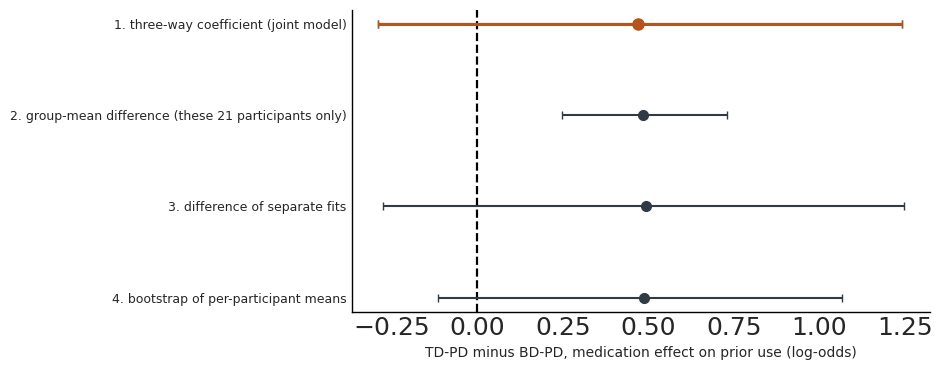

In [9]:
POSTERIOR_COLOR = "#B5541D"
fig, ax = plt.subplots(figsize=(9.5, 3.8))
labels = list(comparisons.index)[::-1]
rows = comparisons.loc[labels]
positions = np.arange(len(labels))
ax.axvline(0, color="k", ls="--", lw=1.6, zorder=1)
ax.errorbar(rows["mean"], positions, xerr=[rows["mean"] - rows["2.5%"], rows["97.5%"] - rows["mean"]],
            ls="", marker="o", ms=7, color="#2F3A45", capsize=3, lw=1.5)
ax.errorbar(rows["mean"].iloc[-1], positions[-1], xerr=[[rows["mean"].iloc[-1] - rows["2.5%"].iloc[-1]],
            [rows["97.5%"].iloc[-1] - rows["mean"].iloc[-1]]], ls="", marker="o", ms=8,
            color=POSTERIOR_COLOR, capsize=3, lw=2.2)
ax.set_yticks(positions)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("TD-PD minus BD-PD, medication effect on prior use (log-odds)", fontsize=10)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "subtype_comparison.pdf", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "subtype_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


## How many participants would settle it?

A rough planning calculation, not a formal power analysis. For a between-participant difference
`delta` with between-participant SD `sigma`, the standard error with `n` per subtype is about
`sigma * sqrt(2 / n)`. The interval excludes zero with probability `power` when
`n = 2 * sigma**2 * ((1.96 + z_power) / delta)**2`.

`sigma` is taken two ways. The lower value is the posterior mean of `sd_u[col:med]`, true
between-participant spread only. The upper value adds each participant's own posterior uncertainty,
since a new participant's effect is also measured with noise. `delta` is the observed three-way
posterior mean. If the true difference is smaller, more participants are needed.


In [10]:
sigma_between = sd_u[..., WITHIN.index("col:med")].mean()
within_noise = participant_effects.std(axis=0).mean()
sigma_total = np.sqrt(sigma_between**2 + within_noise**2)
delta = scm.mean()

planning = pd.DataFrame(
    {f"sigma = {s:.2f} ({label})": {
        f"{int(power * 100)}% power": int(np.ceil(2 * s**2 * ((stats.norm.ppf(0.975) + stats.norm.ppf(power)) / delta) ** 2))
        for power in (0.5, 0.8)}
     for s, label in [(sigma_between, "between only"), (sigma_total, "with measurement noise")]}
).T
print(f"delta = {delta:.2f}; current sample: {(participant_sub > 0).sum()} TD-PD and {(participant_sub < 0).sum()} BD-PD")
print("participants needed per subtype:")
planning


delta = 0.47; current sample: 11 TD-PD and 10 BD-PD
participants needed per subtype:


,50% power,80% power
sigma = 0.81 (between only),23,47
sigma = 0.85 (with measurement noise),26,52


## Results and interpretation

Values are from this run. The fit is deterministic under the fixed seed, and two consecutive runs
gave identical output.

| Estimate | TD-PD minus BD-PD | 95% interval | P(> 0) |
|---|---|---|---|
| **Joint model, three-way coefficient** | **+0.47** | **-0.29 to +1.24** | **0.90** |
| Difference of the separately fitted models | +0.49 | -0.28 to +1.25 | 0.91 |
| Group-mean difference, these 21 participants only | +0.49 | +0.25 to +0.73 | 1.00 |
| Bootstrap of per-participant means | +0.49 | -0.12 to +1.07 | 0.95 (share of resamples) |

**The subtypes are not shown to differ.** The two estimates that answer the population question, the
joint model and the separate fits, agree closely. There is about a 90% posterior probability that
medication increases prior use more in TD-PD than in BD-PD, but the interval includes zero. The
direction fits the within-subtype results, and the evidence is at the same level as the TD-PD
interaction itself.

**The two narrower estimates do not change that.** The group-mean difference excludes zero only
because it conditions on these 21 participants. The bootstrap treats shrunken posterior means as exact.
See the section above.

**Consistency.** The joint model reproduces both within-subtype interactions: TD-PD +0.52 against
+0.53 separately, BD-PD +0.05 against +0.04. In the joint model the TD-PD interval is
[+0.005, +1.05], which technically excludes zero, against [-0.02, +1.09] from the separate fit. That
narrowing comes from sharing between-participant SDs across subtypes, and it is not new evidence:
P(> 0) is 0.977 against 0.970. Report the separately fitted estimate as in Figure 2; switching to
whichever version excludes zero would be a forking-paths choice.

**Why this is hard to settle.** Between-participant variation in the medication effect (SD about
0.85, see `2.26`) is large relative to a difference of about 0.5. With 10-11 participants per subtype,
the standard error of the difference is about 0.37. The planning table above gives the sample needed.
If the true difference is about this size, 23-26 per subtype would give even odds of the interval
excluding zero, and 47-52 per subtype would give 80% power, roughly 2 and 4.5 times the current sample.

### Reporting

Report estimate 1 as the test, with estimate 3 as the check that relaxes the shared-variance
assumption. Describe the result as a difference in the expected direction that the data do not
establish. Do not report estimates 2 or 4 as evidence of subtype specificity.


## Save


In [11]:
comparisons.to_csv(OUTPUT_DIR / "subtype_comparison.csv")
np.savez_compressed(OUTPUT_DIR / "subtype_comparison_draws.npz", beta=beta, sd_u=sd_u,
                    terms=np.asarray(JOINT_TERMS), participants=np.asarray(participants, dtype=str),
                    participant_sub=participant_sub)
for f in sorted(OUTPUT_DIR.glob("subtype_comparison*")):
    print(f"wrote {f.relative_to(OUTPUT_DIR.parent)}")


wrote outputs/subtype_comparison.csv
wrote outputs/subtype_comparison.pdf
wrote outputs/subtype_comparison.png
wrote outputs/subtype_comparison_draws.npz
